Part 4: Data Visualization & Machine Learning

Theme: Student Performance Analysis & Prediction

Task 1: Data Exploration with Pandas 

In [1]:
import panda as pd
import numpy as np

# Load dataset
df = pd.read_csv("students.csv")

if 'passed' not in df.columns:
	if df.shape[1] == 1:
		df = df.iloc[:, 0].str.split(",", expand=True)
		df.columns = ['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']
	else:
		raise KeyError("Column 'passed' not found after reading CSV, check delimiter/header in students.csv")

# convert numeric columns
numeric_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']
for col in numeric_cols:
	df[col] = pd.to_numeric(df[col], errors='coerce')

# 1. First 5 rows
print("First 5 rows:")
print(df.head())

# 2. Shape and data types
print("\nShape of dataset (rows, columns):")
print(df.shape)

print("\nData types of each column:")
print(df.dtypes)

# 3. Summary statistics
print("\nSummary statistics:")
print(df.describe())

# 4. Count of passed and failed students
print("\nPass/Fail counts:")
print(df['passed'].value_counts())

# 5. Average score per subject for pass/fail students

subject_cols = ['math', 'science', 'english', 'history', 'pe']
passed_avg = df[df['passed'] == 1][subject_cols].mean()
failed_avg = df[df['passed'] == 0][subject_cols].mean()

print("\nAverage scores for PASSING students:")
print(passed_avg)

print("\nAverage scores for FAILING students:")
print(failed_avg)

# 6. Student with highest overall average
df['average_score'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['average_score'].idxmax()]

print("\nStudent with highest overall average:")
print(top_student)



First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of dataset (rows, columns):
(15, 9)

Data types of each column:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary statistics:


Task 2: Data Visualization with Matplotlib

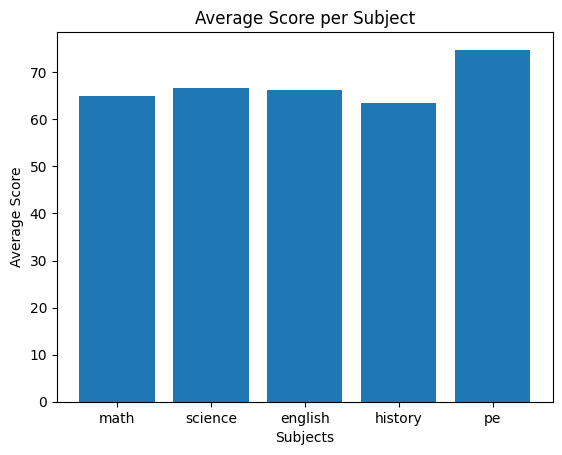

In [4]:
# Importing matplotlib for visualization
import matplotlib.pyplot as plt

# Use existing df (already parsed in previous cell)
# If running this cell standalone, enforce same parsing as before
if 'passed' not in df.columns:
	if df.shape[1] == 1:
		df = df.iloc[:, 0].str.split(",", expand=True)
		df.columns = ['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']
	else:
		raise KeyError("Column 'passed' not found after reading CSV, check delimiter/header in students.csv")

numeric_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']
for col in numeric_cols:
	df[col] = pd.to_numeric(df[col], errors='coerce')

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. Bar chart (average score per subject)
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()



2. Histogram: Distribution of Math scores

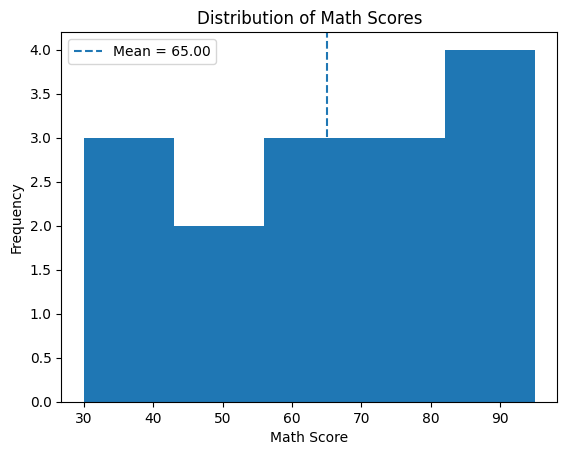

In [5]:

mean_math = df['math'].mean()

plt.figure()
plt.hist(df['math'], bins=5)

plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_histogram.png")
plt.show()



3. Scatter Plot: Study Hours vs Average Score

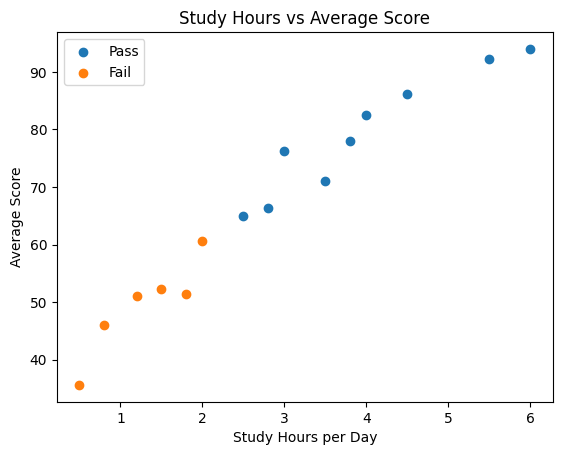

In [6]:

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure()
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()


4. Box Plot: Distribution of Attendance (Pass vs Fail)

C:\Users\sriva\AppData\Local\Temp\ipykernel_33548\2859896881.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


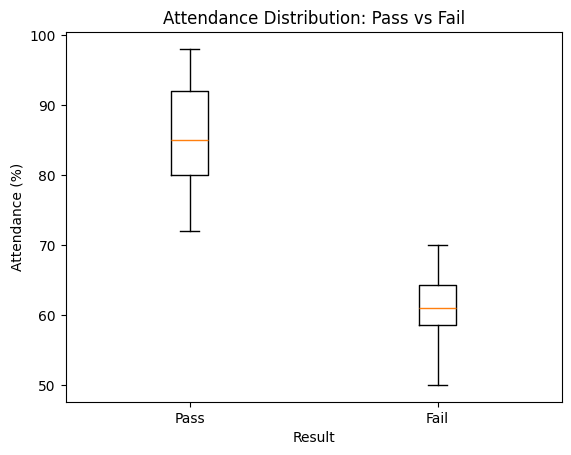

In [8]:
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title("Attendance Distribution: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance (%)")

plt.savefig("plot4_boxplot.png")
plt.show()


5. Line Plot: Math and Science Scores per student

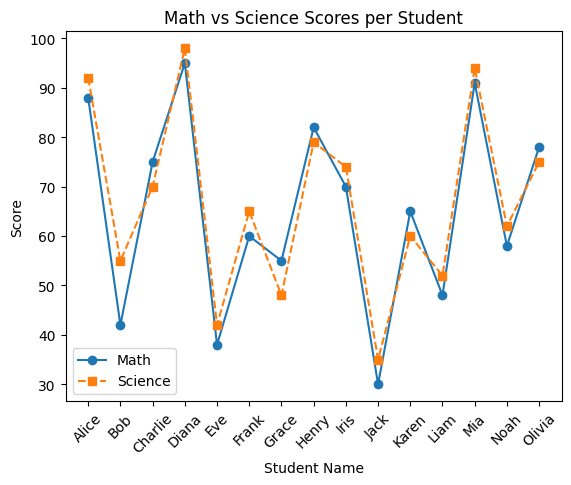

In [10]:

plt.figure()

plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science')

plt.title("Math vs Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()


Task 3: Data Visualization with Seaborn

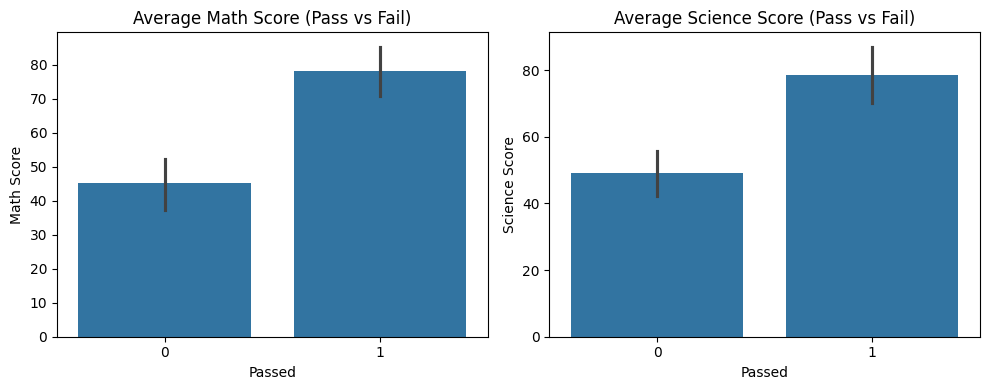

In [13]:
import seaborn as sns

# Load dataset
df = pd.read_csv("students.csv")

if 'passed' not in df.columns:
	if df.shape[1] == 1:
		df = df.iloc[:, 0].str.split(",", expand=True)
		df.columns = ['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']
	else:
		raise KeyError("Column 'passed' not found after reading CSV, check delimiter/header in students.csv")

# convert numeric columns
numeric_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']
for col in numeric_cols:
	df[col] = pd.to_numeric(df[col], errors='coerce')

# Create avg_score (needed for scatter plot)
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

#1. Bar Plot: Avg Math and Science scores vs Pass/Fail
plt.figure(figsize=(10, 4))

# Subplot 1: Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed")
ax1.set_ylabel("Math Score")

# Subplot 2: Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("seaborn_barplots.png")
plt.show()



2. Scatter Plot: Attendance vs Average Score

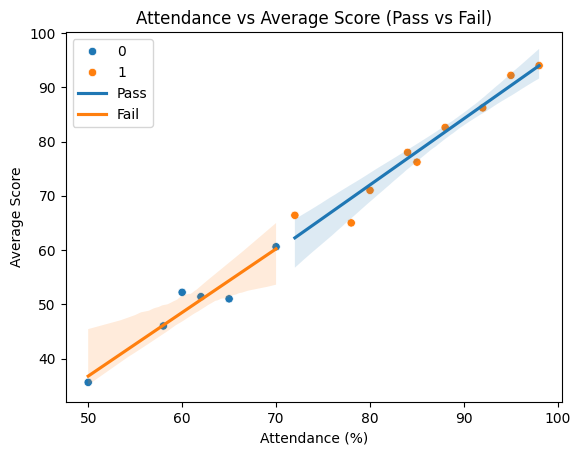

In [16]:

plt.figure()

# Scatter plot
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for PASS students
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# Regression line for FAIL students
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("seaborn_scatter_reg.png")
plt.show()

# Comment: Seaborn vs Matplotlib 
# Seaborn made it much easier to create visually appealing plots with less code.
# It is especially goood for grouped comparisons like bar plots and scatter plots and automatically handles aesthetics.
# In contrast, Matplotlib requires more code to achieve similar visalizations and often needs manual adjustments.
# It handles statistical elements like regression lines more conveniently.

Task 4: Machine Learning with scikit-learn 

Columns: ['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']
Using features: ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
Training Accuracy: 1.0

Test Accuracy: 1.0

Test Predictions:
Jack: Actual=0, Predicted=0: ✅ Correct
Liam: Actual=0, Predicted=0: ✅ Correct
Alice: Actual=1, Predicted=1: ✅ Correct

Feature Importance (sorted):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


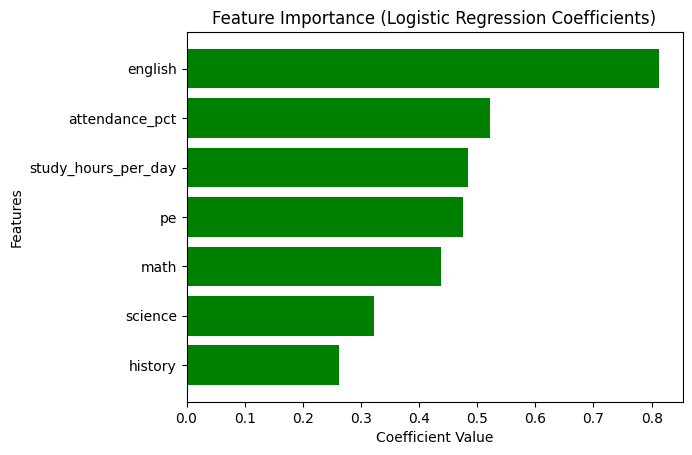


New Student Prediction: Pass
Probability [Fail, Pass]: [0.09203526 0.90796474]


c:\Users\sriva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("students.csv")

# Handle csv without proper delimiter parsing (single-column content from previous behavior)
if 'passed' not in df.columns:
	if df.shape[1] == 1:
		df = df.iloc[:, 0].str.split(",", expand=True)
		df.columns = ['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']
	else:
		raise KeyError("Column 'passed' not found after reading CSV, check delimiter/header in students.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)

print("Columns:", df.columns.tolist())

# convert numeric columns
numeric_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day', 'passed']
for col in numeric_cols:
	df[col] = pd.to_numeric(df[col], errors='coerce')

#Step 1 — Prepare Data

# Features and target
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
feature_cols = [col for col in feature_cols if col in df.columns]

print("Using features:", feature_cols)
X = df[feature_cols]
y = df['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Step 2 — Train Model
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

# Training accuracy
train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_acc)

#Step 3 — Evaluate the Model

# Test predictions
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", test_acc)

# Detailed output with student names
print("\nTest Predictions:")

for index, actual, pred in zip(X_test.index, y_test, y_pred):
    name = df.loc[index, 'name'] if 'name' in df.columns else f"Student_{index}" 
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred}: {status}")

#Step 4 - Feature Importance (Coefficients)
coefficients = model.coef_[0]

# Pair with feature names
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")

#plotting feature importance
features = [f[0] for f in feature_importance]
coefs = [f[1] for f in feature_importance]

colors = ['green' if c > 0 else 'red' for c in coefs]

plt.figure()
plt.barh(features, coefs, color=colors)

plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.gca().invert_yaxis()  # highest at top

plt.savefig("feature_importance.png")
plt.show()

#Step 5 - Prediction for a new student

# New student (order must match feature_cols)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Scale
new_student_scaled = scaler.transform(new_student)

# Prediction
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction else "Fail"

print("\nNew Student Prediction:", result)
print("Probability [Fail, Pass]:", probability)




